# Practical Introduction to Multiresolution Analysis

This example shows how to perform and interpret basic signal multiresolution analysis (MRA). The example uses both simulated and real data to answer questions such as: What does multiresolution analysis mean? What insights about my signal can I gain performing a multiresolution analysis? What are some of the advantages and disadvantages of different MRA techniques? 

## What Is Multiresolution Analysis?
Signals often consist of multiple physically meaningful components. Quite often, you want to study one or more of these components in isolation on the same time scale as the original data. Multiresolution analysis refers to breaking up a signal into components, which produce the original signal exactly when added back together. To be useful for data analysis, how the signal is decomposed is important. The components ideally decompose the variability of the data into physically meaningful and interpretable parts. The term multiresolution analysis is often associated with wavelets or wavelet packets, but there are non-wavelet techniques which also produce useful MRAs.

As a motivating example of the insights you can gain from an MRA, consider the following synthetic signal. The signal is sampled at 1000 Hz for one second.

In [40]:
#!pip install EMD-signal
#!pip install vmdpy
# pip install PyWavelets

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.fft import fft
import pywt
np.random.seed(0)

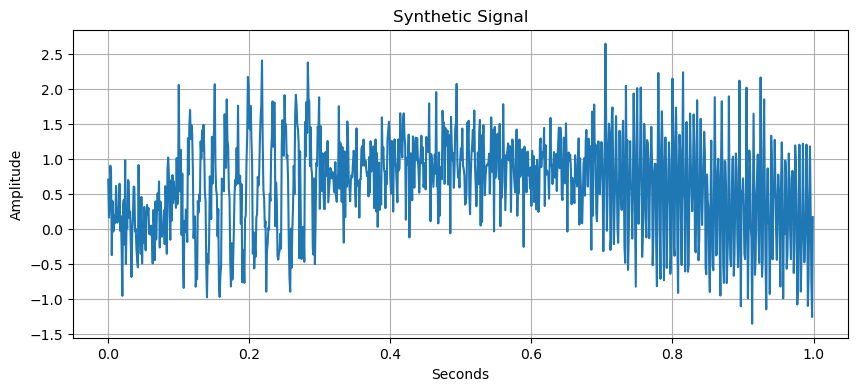

In [2]:

# 1. Setup time vector
Fs = 1e3
t = np.arange(0, 1, 1/Fs)

# 2. Create signal components
# Note: In Python, boolean masks (t > 0.7) work just like MATLAB's
comp1 = np.cos(2 * np.pi * 200 * t) * (t > 0.7)
comp2 = np.cos(2 * np.pi * 60 * t) * ((t >= 0.1) & (t < 0.3))
trend = np.sin(2 * np.pi * 0.5 * t)

# 3. Generate noise
# np.random.seed(0) is the equivalent of 'rng default'
np.random.seed(0)
wgnNoise = 0.4 * np.random.randn(len(t))

# 4. Sum components
x = comp1 + comp2 + trend + wgnNoise

# 5. Plotting
plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.xlabel("Seconds")
plt.ylabel("Amplitude")
plt.title("Synthetic Signal")
plt.grid(True)
plt.show()

In [3]:
def fft_analysis(signal):

    # # Linear detrending
    # slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1)
    # trend = np.arange(len(signal)) * slope + intercept
    # detrended = signal - trend

    fft_values = fft(signal)
    frequencies = np.fft.fftfreq(len(fft_values),1/len(signal))

    # Remove negative frequencies and sort
    positive_frequencies = frequencies[frequencies > 0]
    magnitudes = np.abs(fft_values)[frequencies > 0]

    # Identify dominant frequency
    dominant_frequency = positive_frequencies[np.argmax(magnitudes)]
    print(f"Dominant Frequency: {dominant_frequency:.3f}")

    # Convert frequency to period (e.g., days, weeks, months, etc.)
    dominant_period = 1 / dominant_frequency
    print(f"Dominant Period: {dominant_period:.2f} time units")

    return dominant_period, positive_frequencies, magnitudes

In [4]:
period, freqs, magnitudes = fft_analysis(x)

Dominant Frequency: 1.000
Dominant Period: 1.00 time units


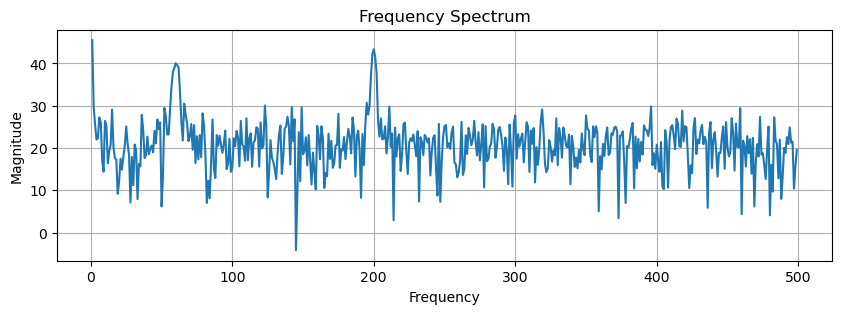

In [5]:
# Plotting the spectrum
plt.figure(figsize=(10, 3))
plt.plot(freqs, 20*np.log10(np.abs(magnitudes)))
plt.title('Frequency Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

The signal is explicitly composed of three main components: a time-localized oscillation with a frequency of 60 cycles/second, a time-localized oscillation with a frequency of 200 cycles/second, and a trend term. The trend term here is also sinusoidal but has a frequency of 1/2 cycle per second, so it completes only 1/2 cycle in the one-second interval. The 60 cycles/second or 60 Hz oscillation occurs between 0.1 and 0.3 seconds, while the 200 Hz oscillation occurs between 0.7 and 1 second.

Not all of this is immediately evident from the plot of the raw data because these components are mixed.

Now, plot the signal from a frequency point of view.

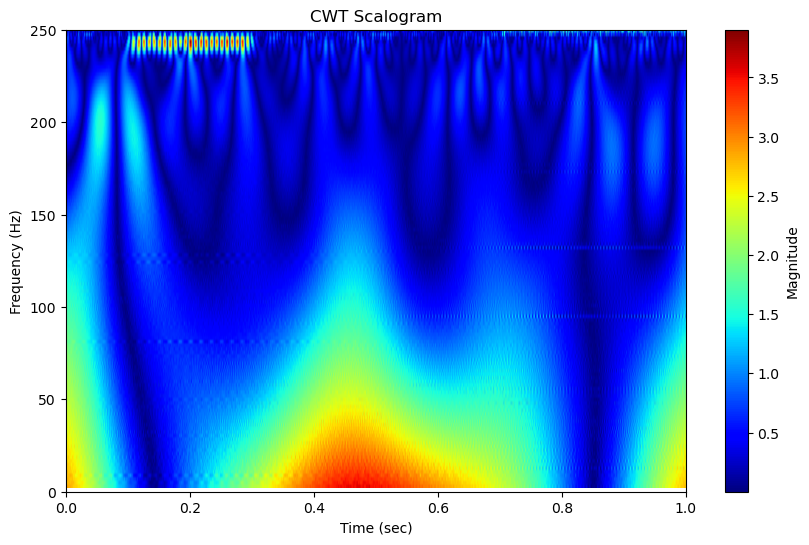

In [50]:
scales = np.arange(1, 128) 

# 2. Perform CWT using the 'cmor' (Complex Morlet) wavelet
# 'cmor1.5-1.0' is a common choice that mimics MATLAB's default behavior
coef, freqs = pywt.cwt(x, scales, 'mexh', sampling_period=1/Fs)

# 3. Plotting the Scalogram
plt.figure(figsize=(10, 6))
# np.abs(coef) is used because CWT produces complex numbers
plt.imshow(np.abs(coef), extent=[0, 1, freqs[-1], freqs[0]], 
           aspect='auto', cmap='jet')

plt.title("CWT Scalogram")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (sec)")
plt.colorbar(label="Magnitude")
plt.ylim(0, 250) # Zooming in on your 60Hz and 200Hz components
plt.show()

Now you see the time extents of the 60 Hz and 200 Hz components. However, we still do not have any useful visualization of the trend.

The time-frequency view provides useful information, but in many situations you would like to separate out components of the signal in time and examine them individually. Ideally, you want this information to be available on the same time scale as the original data.

Multiresolution analysis accomplishes this. In fact, a useful way to think about multiresolution analysis is that it provides a way of avoiding the need for time-frequency analysis while allowing you to work directly in the time domain.

## Separating Signal Components in Time
Real-world signals are a mixture of different components. Often you are only interested in a subset of these components. Multiresolution analysis allows you to narrow your analysis by separating the signal into components at different resolutions.

Extracting signal components at different resolutions amounts to decomposing variations in the data on different time scales, or equivalently in different frequency bands (different rates of oscillation). Accordingly, you can visualize signal variability at different scales, or frequency bands simultaneously.

Analyze and plot the synthetic signal using a wavelet MRA. The signal is analyzed at eight resolutions or levels.

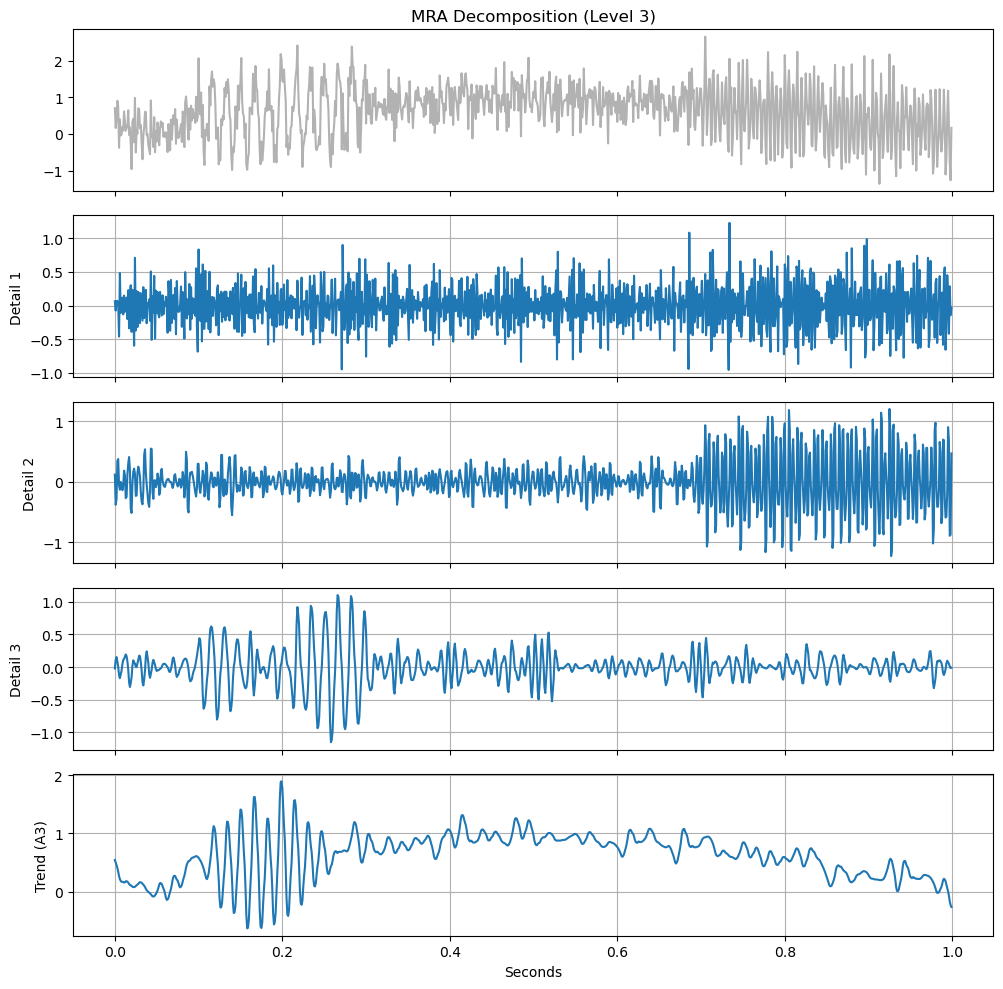

In [25]:
# 1. Setup
wavelet = 'db4'
level = 3  # Change this to 5, 7, or 8 and the plot will adapt!
coeffs = pywt.wavedec(x, wavelet, level=level)

# 2. Reconstruct MRA Components
mra = []
for i in range(len(coeffs)):
    zeros = [np.zeros_like(c) for c in coeffs]
    zeros[i] = coeffs[i]
    reconstructed = pywt.waverec(zeros, wavelet)
    mra.append(reconstructed[:len(x)])

# 3. Adaptive Indexing & Labeling
# In Python's wavedec order:
# mra[0] is always the Approximation (Trend)
# mra[-j] is Detail j

target_details = list(np.arange(1,level+1))  # The "D" levels you want to see
indices = []
labels = []

for d in target_details:
    if d <= level:
        indices.append(-d) # D2 is at -2, D3 is at -3, etc.
        labels.append(f"Detail {d}")

# Always add the Approximation (Trend) at the end
indices.append(0)
labels.append(f"Trend (A{level})")

# 4. Plotting
fig, axes = plt.subplots(len(indices) + 1, 1, figsize=(10, 2 * (len(indices) + 1)), sharex=True)

axes[0].plot(t, x, color='black', alpha=0.3)
axes[0].set_title(f"MRA Decomposition (Level {level})")

for i, idx in enumerate(indices):
    axes[i+1].plot(t, mra[idx])
    axes[i+1].set_ylabel(labels[i])
    axes[i+1].grid(True)

plt.xlabel("Seconds")
plt.tight_layout()
plt.show()

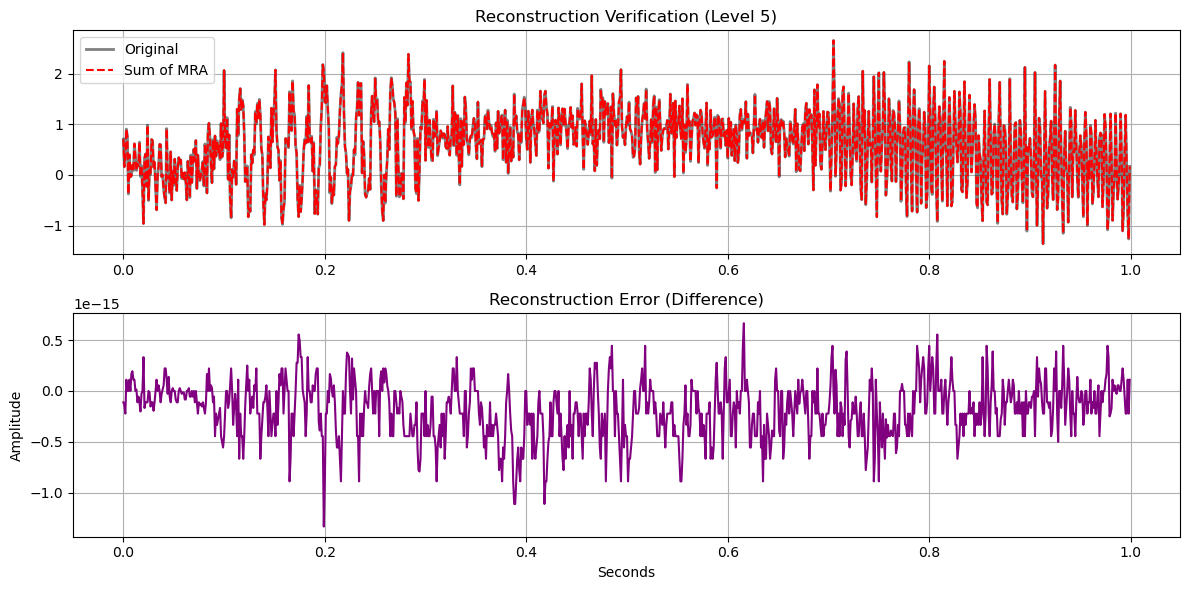

Maximum absolute error: 1.3322676295501878e-15


In [24]:
#1. Sum all reconstructed components
# np.sum(mra, axis=0) adds all the arrays in the list together
reconstructed_x = np.sum(mra, axis=0)

# 2. Calculate the "Residual" or Error
# Ideally, this should be very close to zero (e.g., 1e-12)
error = x - reconstructed_x

# 3. Plotting the Comparison
plt.figure(figsize=(12, 6))

# Subplot 1: Original vs Reconstructed
plt.subplot(2, 1, 1)
plt.plot(t, x, label="Original", color='black', alpha=0.5, lw=2)
plt.plot(t, reconstructed_x, label="Sum of MRA", color='red', linestyle='--')
plt.title(f"Reconstruction Verification (Level {level})")
plt.legend()
plt.grid(True)

# Subplot 2: The Difference (Error)
plt.subplot(2, 1, 2)
plt.plot(t, error, color='purple')
plt.title("Reconstruction Error (Difference)")
plt.ylabel("Amplitude")
plt.xlabel("Seconds")
plt.grid(True)

plt.tight_layout()
plt.show()

# Print the maximum error value
print(f"Maximum absolute error: {np.max(np.abs(error))}")

# Empirical Mode Decomposition
Moving from Wavelets to Empirical Mode Decomposition (EMD) is a shift from using a fixed "ruler" (the wavelet) to a data-driven approach. Instead of pre-defined frequency bands, EMD breaks the signal into Intrinsic Mode Functions (IMFs) based on the local oscillations of the data itself.

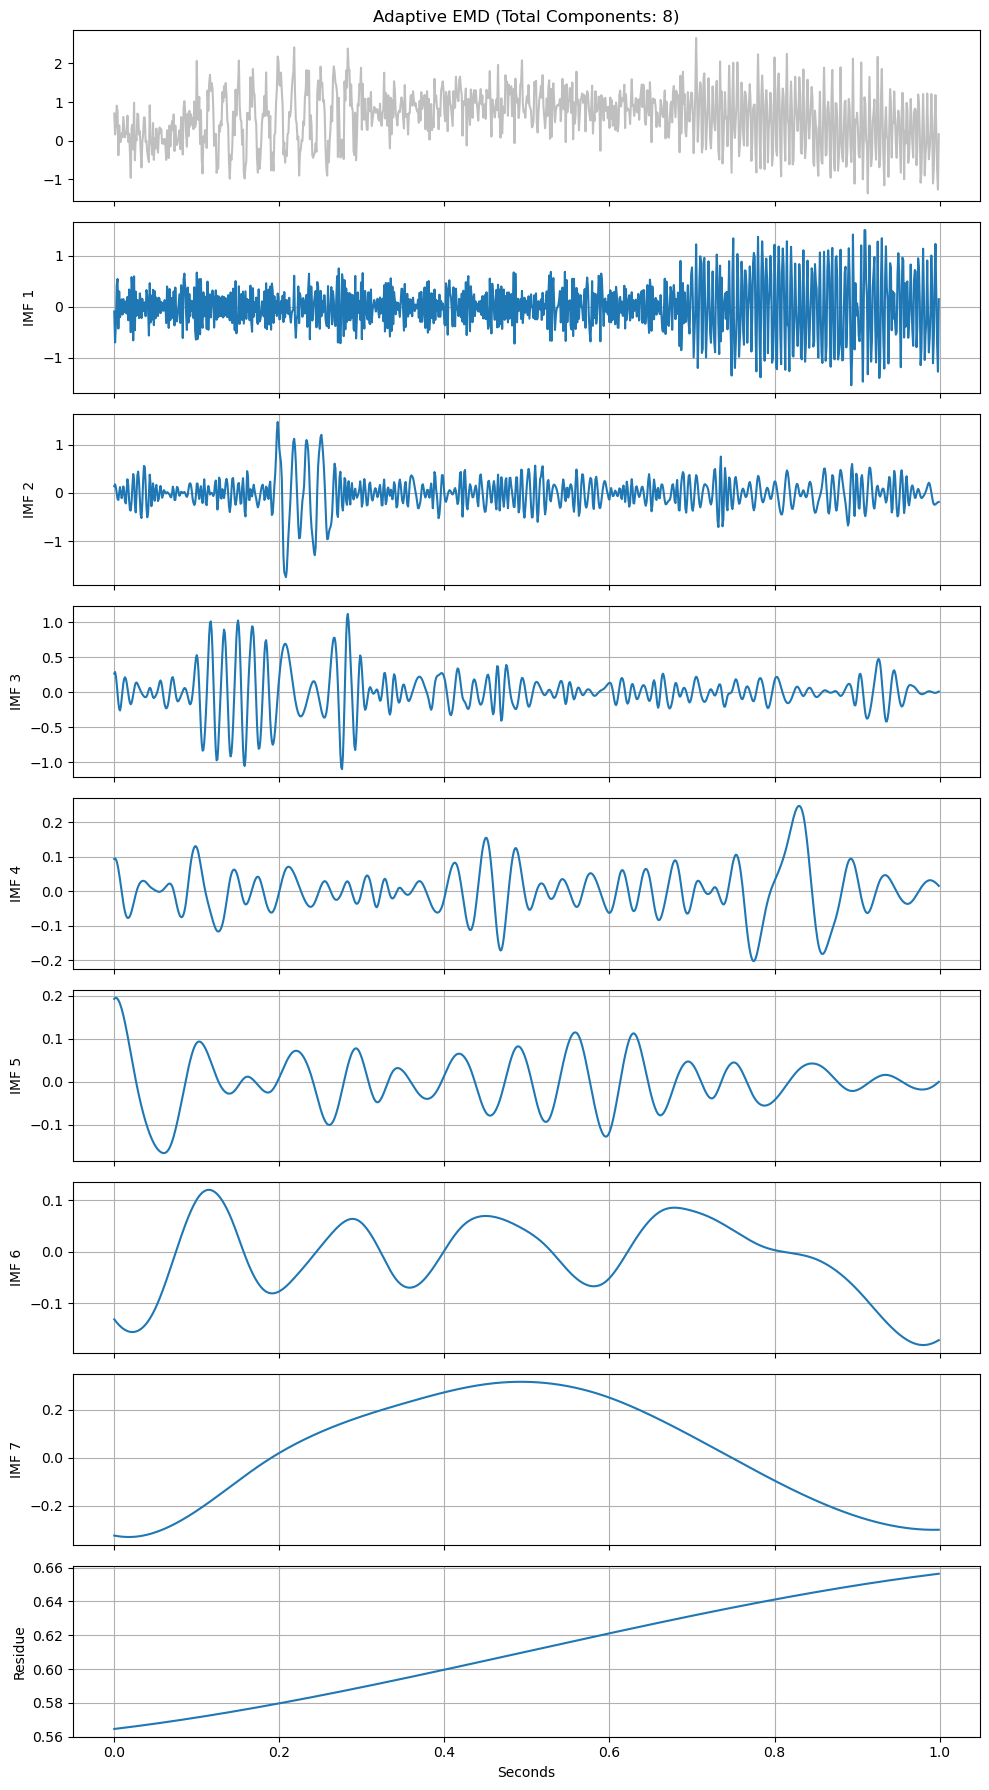

In [32]:
from PyEMD import EMD
from PyEMD import EMD
import numpy as np
import matplotlib.pyplot as plt

# 1. Perform EMD
emd = EMD()
imfs = emd(x)  # imfs is a 2D array: [num_imfs, signal_length]
num_total = imfs.shape[0]

# 2. Define which IMFs you want to see
# Let's say we want the first 3 (high freq) and the Residue (last one)
# We use a set to avoid duplicates if the signal is very simple
target_indices = list(np.arange(0,num_total)) 

# Filter indices to ensure they exist (in case EMD produces fewer than 3 IMFs)
indices = [i for i in target_indices if i < num_total]

# 3. Create Adaptive Labels
labels = []
for idx in indices:
    if idx == num_total - 1:
        labels.append("Residue")
    else:
        labels.append(f"IMF {idx + 1}")

# 4. Plotting
fig, axes = plt.subplots(len(indices) + 1, 1, figsize=(10, 2 * (len(indices) + 1)), sharex=True)

# Plot Original Signal
axes[0].plot(t, x, color='gray', alpha=0.5)
axes[0].set_title(f"Adaptive EMD (Total Components: {num_total})")

# Plot Dynamic Components
for i, idx in enumerate(indices):
    axes[i+1].plot(t, imfs[idx])
    axes[i+1].set_ylabel(labels[i])
    axes[i+1].grid(True)

plt.xlabel("Seconds")
plt.tight_layout()
plt.show()

In [30]:
imfs = emd(x)  # imfs is a 2D array: [num_imfs, signal_length]
num_total = imfs.shape[0]
num_total

8

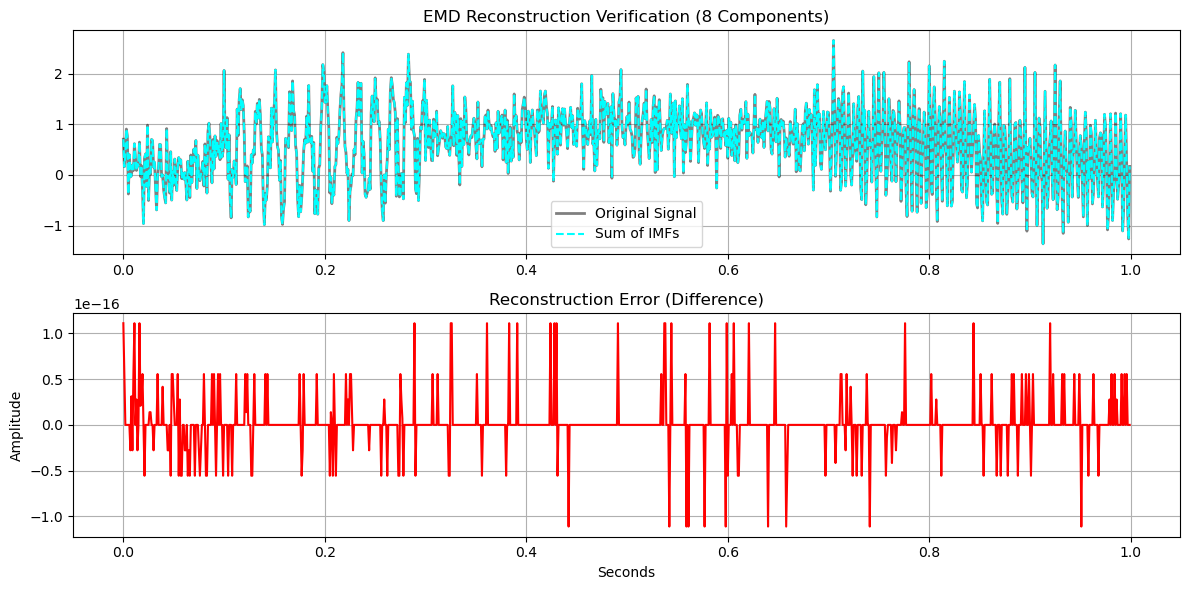

Total IMFs + Residue: 8
Maximum absolute error: 1.1102230246251565e-16


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Sum all IMFs (including the residue)
# axis=0 sums across the rows (the components)
reconstructed_x_emd = np.sum(imfs, axis=0)

# 2. Calculate the reconstruction error
# EMD is generally very precise, but numerical sifting can leave tiny residuals
emd_error = x - reconstructed_x_emd

# 3. Plotting the Verification
plt.figure(figsize=(12, 6))

# Subplot 1: Comparison
plt.subplot(2, 1, 1)
plt.plot(t, x, label="Original Signal", color='black', alpha=0.5, lw=2)
plt.plot(t, reconstructed_x_emd, label="Sum of IMFs", color='cyan', linestyle='--')
plt.title(f"EMD Reconstruction Verification ({imfs.shape[0]} Components)")
plt.legend()
plt.grid(True)

# Subplot 2: Error
plt.subplot(2, 1, 2)
plt.plot(t, emd_error, color='red')
plt.title("Reconstruction Error (Difference)")
plt.ylabel("Amplitude")
plt.xlabel("Seconds")
plt.grid(True)

plt.tight_layout()
plt.show()

# Print the precision check
print(f"Total IMFs + Residue: {imfs.shape[0]}")
print(f"Maximum absolute error: {np.max(np.abs(emd_error))}")

# How to use this for "Denoising"
In EMD, the first IMF almost always contains the highest frequency white noise. If you want a "clean" version of your signal, you can sum everything except the first IMF:

In [34]:
clean_signal = np.sum(imfs[1:], axis=0)

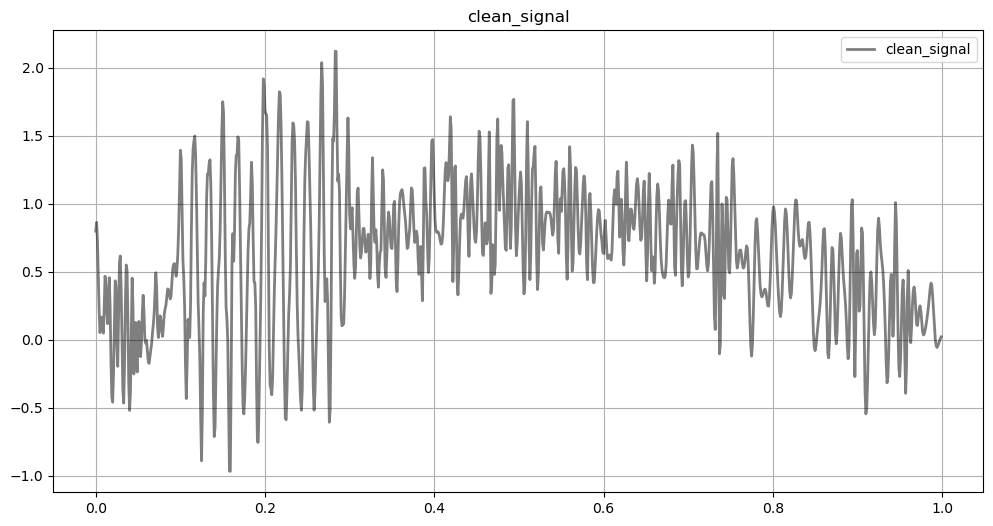

In [35]:
plt.figure(figsize=(12, 6))

# Subplot 1: Comparison
plt.plot(t, clean_signal, label="clean_signal", color='black', alpha=0.5, lw=2)

plt.title(f"clean_signal")
plt.legend()
plt.grid(True)


In standard Empirical Mode Decomposition (EMD), the number of IMFs is determined by the data itself—the algorithm keeps "sifting" until it can't find any more oscillations. You cannot strictly "force" the basic EMD to stop at exactly 3 IMFs without potentially breaking the mathematical properties of the Intrinsic Mode Functions.
However, there are three professional ways to handle this in Python depending on your goal:

1. The "Summation" Method (Post-Processing)
If you want 3 components because you want to group the results (e.g., High Frequency, Low Frequency, and Trend), you simply sum the IMFs you've already generated. This is the most mathematically sound approach.
2. Using VMD (Variational Mode Decomposition)If you need a fixed number of components, engineers usually switch from EMD to VMD. In VMD, the number of modes ($K$) is a required input.


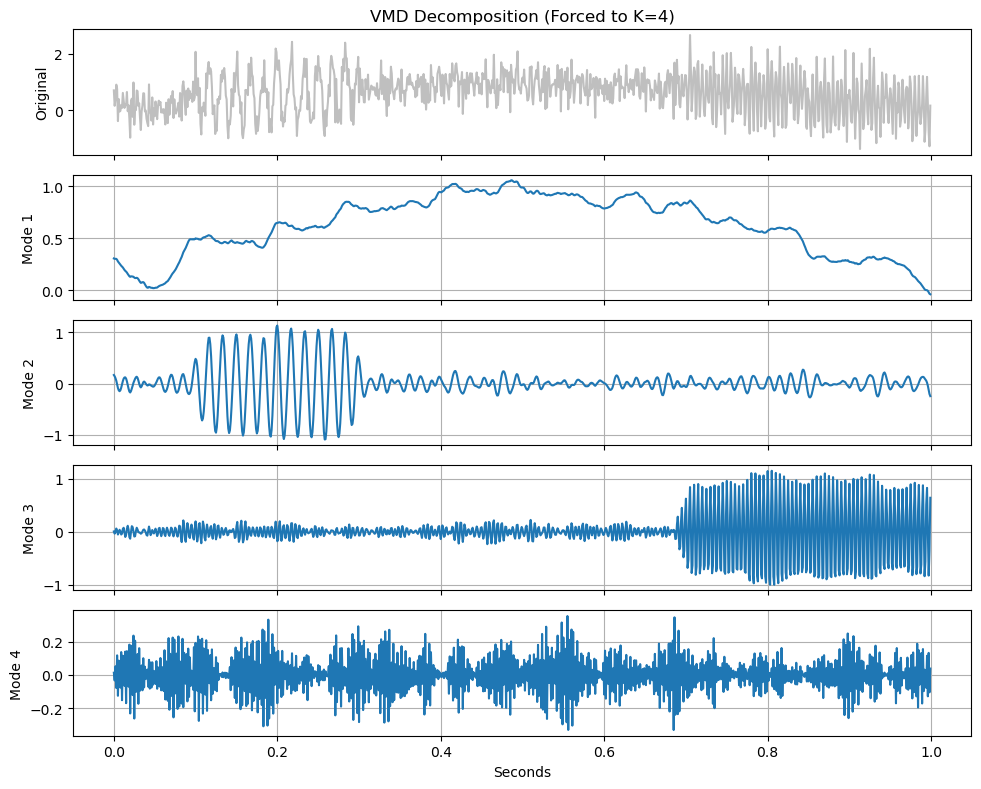

VMD Reconstruction Max Error: 0.7855687135549354


In [44]:

from vmdpy import VMD

# --- VMD Parameters ---
# alpha: balancing parameter of the data-fidelity constraint (standard is 2000)
# tau: time-step of the dual ascent (standard is 0)
# K: THE NUMBER OF COMPONENTS YOU WANT (set to 3)
# DC: 1 if you want a DC component, 0 if not
# init: 1 to initialize omegas uniformly
# tol: tolerance of convergence criterion

K = 4 
alpha = 2000 
tau = 0. 
DC = 0 
init = 1 
tol = 1e-7

# Execute VMD
# u: the collection of decomposed modes (the IMFs)
# u_hat: spectra of the modes
# omega: estimated mode center-frequencies
u, u_hat, omega = VMD(x, alpha, tau, K, DC, init, tol)

# --- Plotting the 3 forced components ---
fig, axes = plt.subplots(K + 1, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, x, color='gray', alpha=0.5)
axes[0].set_title(f"VMD Decomposition (Forced to K={K})")
axes[0].set_ylabel("Original")

for i in range(K):
    axes[i+1].plot(t, u[i])
    axes[i+1].set_ylabel(f"Mode {i+1}")
    axes[i+1].grid(True)

plt.xlabel("Seconds")
plt.tight_layout()
plt.show()

# --- Verification: Sum to original ---
reconstructed_vmd = np.sum(u, axis=0)
print(f"VMD Reconstruction Max Error: {np.max(np.abs(x - reconstructed_vmd))}")

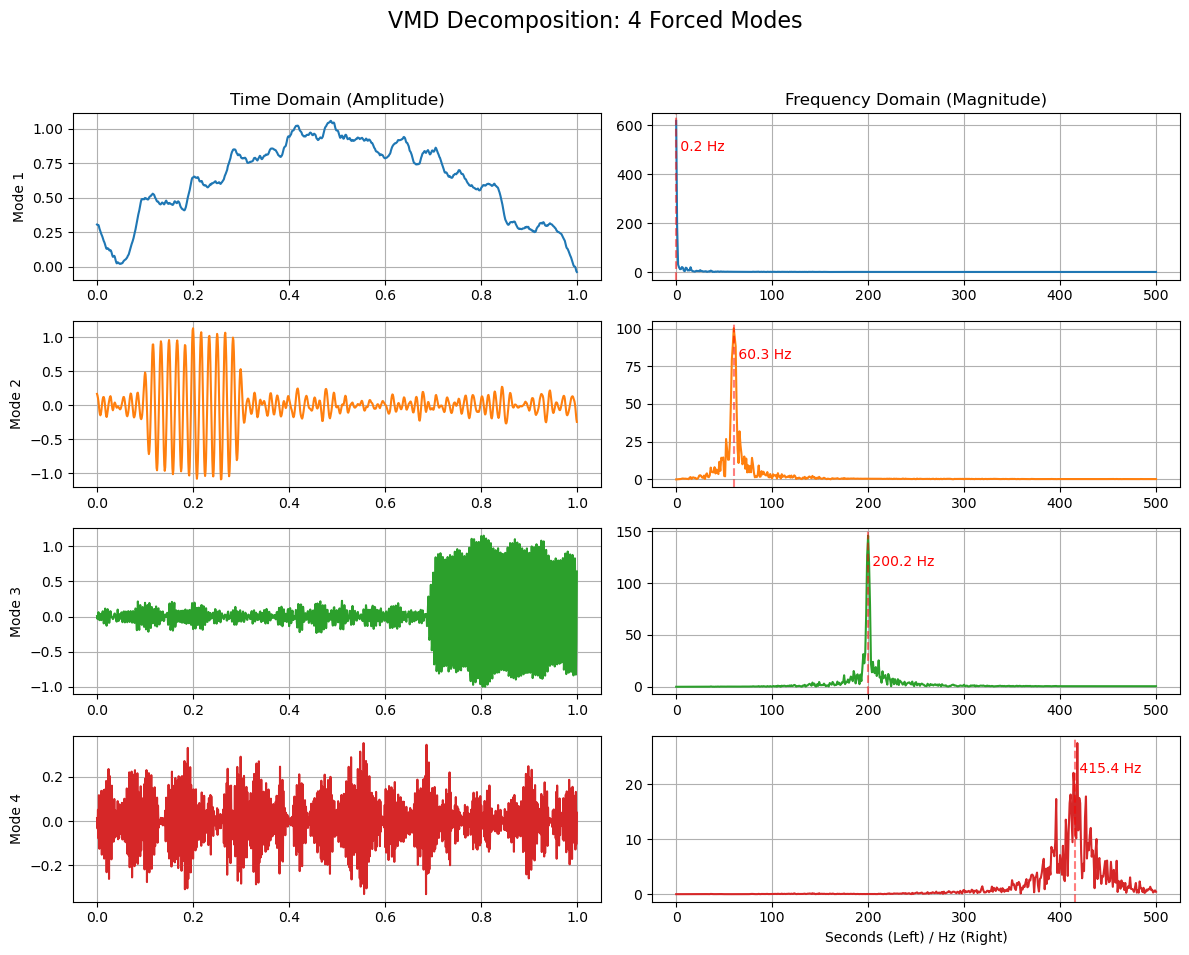

Reconstruction Error (RMS): 2.67e-01


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD

# --- 1. Run VMD (Assuming x, t, and Fs are defined from previous steps) ---
K = 4 
alpha = 2000 
u, u_hat, omega = VMD(x, alpha, 0, K, 0, 1, 1e-7)

# --- 2. Create the Figure ---
fig, axes = plt.subplots(K, 2, figsize=(12, 10))
fig.suptitle(f'VMD Decomposition: {K} Forced Modes', fontsize=16)

# Frequency axis for the spectra
freqs = np.linspace(0, Fs/2, len(t)//2 + 1)

for i in range(K):
    # --- Left Column: Time Domain ---
    axes[i, 0].plot(t, u[i], color='C'+str(i))
    axes[i, 0].set_ylabel(f'Mode {i+1}')
    if i == 0: axes[i, 0].set_title('Time Domain (Amplitude)')
    axes[i, 0].grid(True)
    
    # --- Right Column: Frequency Domain (FFT of the Mode) ---
    mode_fft = np.fft.fft(u[i])
    mag = np.abs(mode_fft[:len(t)//2 + 1])
    
    axes[i, 1].plot(freqs, mag, color='C'+str(i))
    if i == 0: axes[i, 1].set_title('Frequency Domain (Magnitude)')
    
    # Mark the center frequency identified by VMD
    # omega is normalized to [0, 0.5], so we scale by Fs
    center_freq = omega[-1, i] * Fs
    axes[i, 1].axvline(center_freq, color='red', linestyle='--', alpha=0.5)
    axes[i, 1].text(center_freq, np.max(mag)*0.8, f' {center_freq:.1f} Hz', color='red')
    axes[i, 1].grid(True)

plt.xlabel('Seconds (Left) / Hz (Right)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3. Final Verification ---
res = x - np.sum(u, axis=0)
print(f"Reconstruction Error (RMS): {np.sqrt(np.mean(res**2)):.2e}")

3. Limiting EMD via "Max Imf"
While the standard EMD() doesn't always support a "stop at 3" parameter in all versions, some implementations allow you to limit the sifting. In PyEMD, you can't easily force an early exit, but you can achieve a similar effect by manipulating the stopping criteria.

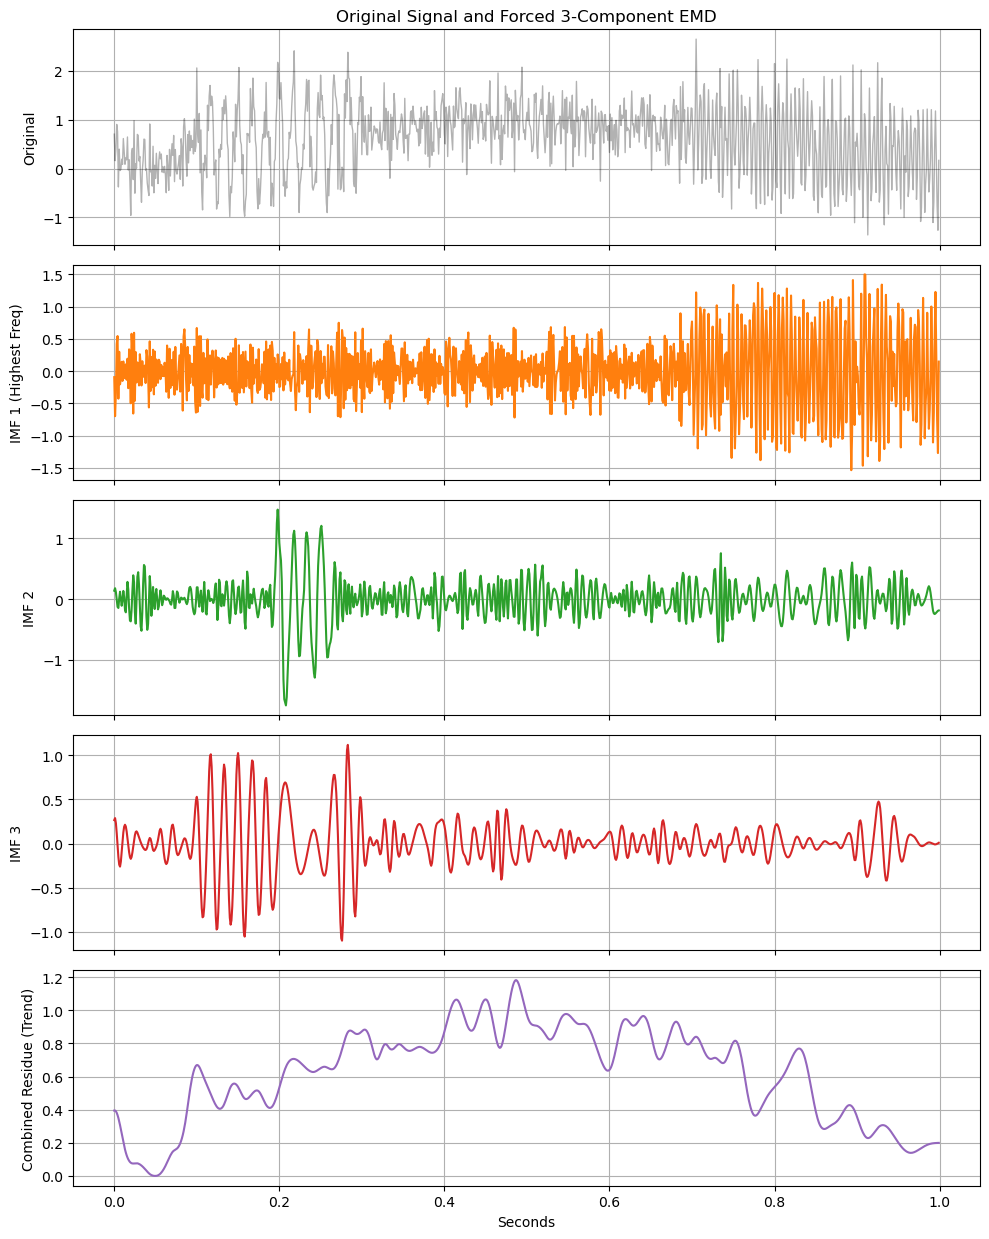

Reconstruction Error: 4.44e-16


In [49]:

# --- 1. Preparation of Components ---
# We use the list you defined to group the data
forced_imfs = [
    imfs[0],
    imfs[1],
    imfs[2],
    np.sum(imfs[3:], axis=0) # Everything else
]
forced_labels = ["IMF 1 (Highest Freq)", "IMF 2", "IMF 3", "Combined Residue (Trend)"]

# --- 2. Plotting ---
num_rows = len(forced_imfs) + 1 # +1 for the original signal
fig, axes = plt.subplots(num_rows, 1, figsize=(10, 2.5 * num_rows), sharex=True)

# Plot Original Signal for reference
axes[0].plot(t, x, color='black', alpha=0.3, lw=1)
axes[0].set_title("Original Signal and Forced 3-Component EMD")
axes[0].set_ylabel("Original")
axes[0].grid(True)

# Plot the 3 Forced Components
for i in range(len(forced_imfs)):
    axes[i+1].plot(t, forced_imfs[i], color=f'C{i+1}') # Uses different colors
    axes[i+1].set_ylabel(forced_labels[i])
    axes[i+1].grid(True)

plt.xlabel("Seconds")
plt.tight_layout()
plt.show()

# --- 3. Verification ---
# Ensuring the summation still equals the original signal
reconstructed_forced = np.sum(forced_imfs, axis=0)
max_err = np.max(np.abs(x - reconstructed_forced))
print(f"Reconstruction Error: {max_err:.2e}")

## Conclusions
This lecture showed how multiresolution decomposition techniques such as wavelet, wavelet packet, empirical mode decomposition, empirical wavelet, and variational mode decomposition allow you to study signal components in relative isolation on the same time scale as the original data. Each technique has proven itself powerful in a number of applications. The example has given a few rules of thumb to get you started, but these should not be regarded as absolute. The following table recaps properties of the MRA techniques presented here along with some general rules of thumb. Two plusses denote a particular strength, one plus indicates that the technique is applicable, but not a particular strength. For a binary property like the preservation of energy in the analysis, a check mark indicates the technique has this property and an "x" indicates the property is absent.
<img src="PracticalIntroductionToMultiresolutionAnalysisExample_25.png" style="width: 70%; display: block; margin: auto;">

# Great Job!